# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

Requirement already up-to-date: plotly in /usr/local/lib/python3.6/dist-packages (4.12.0)


### Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [4]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
df_data.shape
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [6]:
df_data.isnull().any()

Unnamed: 0.1      False
Unnamed: 0        False
Organisation      False
Location          False
Date              False
Detail            False
Rocket_Status     False
Price              True
Mission_Status    False
dtype: bool

<p>How many nan values in respective column?</p>

In [7]:
df_data.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [8]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [9]:
# print(df_data.duplicated().sum())
# print(f"Missing values {df_data.isnull().sum()}")
print(df_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB
None


In [87]:
def parse_dates(date_str):
    date_format = [
        "%a %b %d, %Y %H:%M %Z",
        "%a %b %d, %Y"
    ]

    for fmt in date_format:
        try:
            return pd.to_datetime(date_str, format=fmt, utc=True)
        except ValueError:
            continue
    return pd.NaT


In [89]:
# print("Is Null Values:\n", df_data.isnull().sum())
# print("Duplicates", df_data.duplicated().sum())

cleaned_df = df_data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
cleaned_df["Date"] = cleaned_df["Date"].apply(parse_dates)

cleaned_df["Price"] = pd.to_numeric(cleaned_df["Price"], errors='coerce').astype("float64")
cleaned_df = cleaned_df.dropna(subset=['Price'])

cleaned_df = cleaned_df.drop_duplicates()
# print("Duplicates", cleaned_df.duplicated().sum())

print(cleaned_df.info())
# print(f"Missing values {cleaned_df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
Index: 948 entries, 0 to 4020
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    948 non-null    object             
 1   Location        948 non-null    object             
 2   Date            948 non-null    datetime64[ns, UTC]
 3   Detail          948 non-null    object             
 4   Rocket_Status   948 non-null    object             
 5   Price           948 non-null    float64            
 6   Mission_Status  948 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(5)
memory usage: 59.2+ KB
None


## Descriptive Statistics

In [11]:
cleaned_df.describe()

,Price
count,948.00
mean,129.90
std,143.26
min,5.30
25%,40.00
50%,62.00
75%,164.00
max,450.00


In [12]:
cleaned_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [13]:
no_of_launches = cleaned_df['Organisation'].value_counts()
no_of_launches.columns = ['Organisation', 'No of Launches']
print(no_of_launches)

Organisation
CASC               157
NASA               136
SpaceX              99
ULA                 98
Arianespace         96
Northrop            83
ISRO                67
MHI                 37
VKS RF              33
US Air Force        26
Roscosmos           23
Kosmotras           22
ILS                 13
Eurockot            13
Rocket Lab          13
Martin Marietta      9
Lockheed             8
Boeing               7
JAXA                 3
ExPace               1
Sandia               1
Virgin Orbit         1
ESA                  1
EER                  1
Name: count, dtype: int64


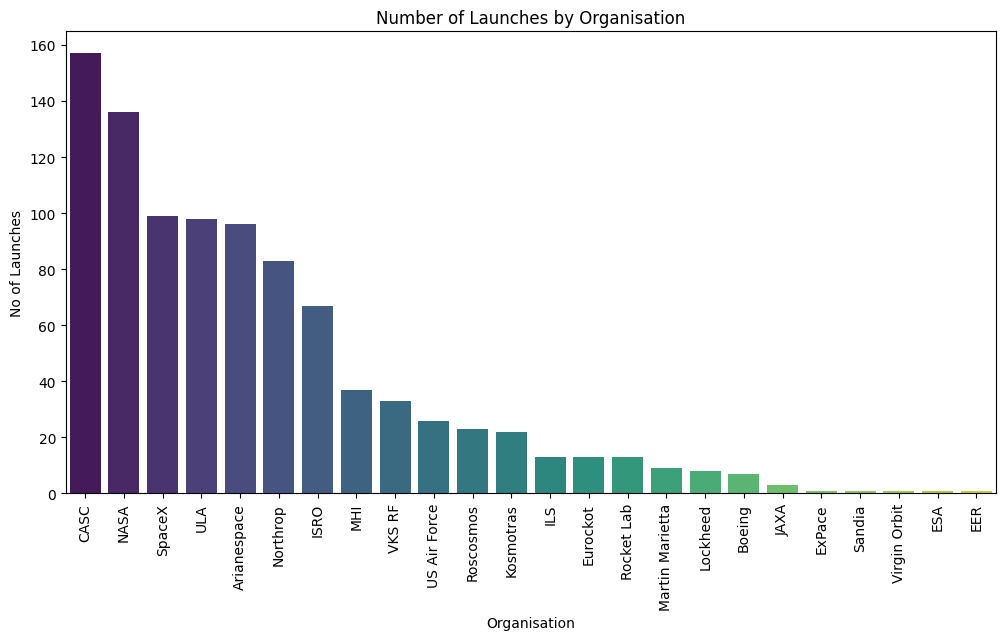

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=no_of_launches.index,
    y=no_of_launches.values,
    palette='viridis',
    hue=no_of_launches.index,
    legend=False
)
plt.xticks(rotation=90)
plt.xlabel('Organisation')
plt.ylabel('No of Launches')
plt.title('Number of Launches by Organisation')
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [15]:
status_counts = cleaned_df['Rocket_Status'].value_counts()
print(status_counts)

Rocket_Status
StatusActive     585
StatusRetired    363
Name: count, dtype: int64


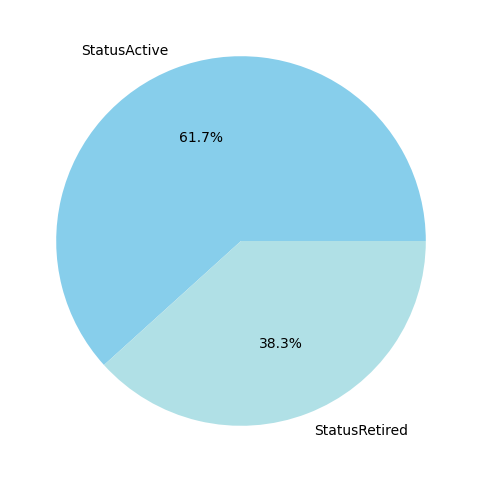

In [16]:
plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=['skyblue', 'powderblue']
)
plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [17]:
mission_status = cleaned_df['Mission_Status'].value_counts()
print(mission_status)

Mission_Status
Success              895
Failure               36
Partial Failure       16
Prelaunch Failure      1
Name: count, dtype: int64


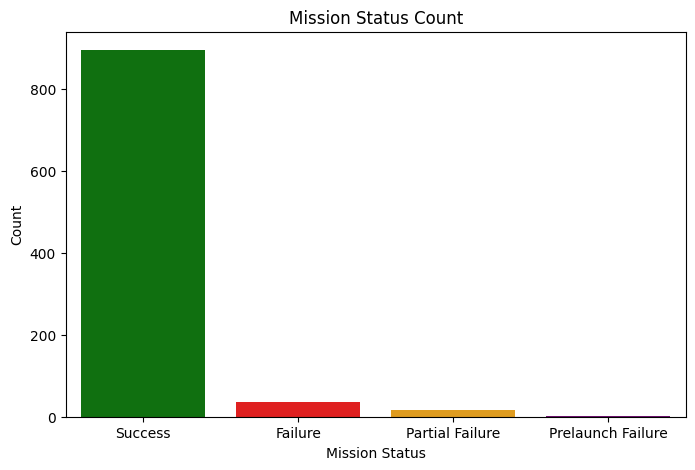

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=mission_status.index,
    y=mission_status.values,
    palette=['green', 'red', 'orange', 'purple'],
    hue=mission_status.index,
    legend=False
)
plt.xlabel('Mission Status')
plt.ylabel('Count')
plt.title('Mission Status Count')
plt.xticks(rotation=0)
plt.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

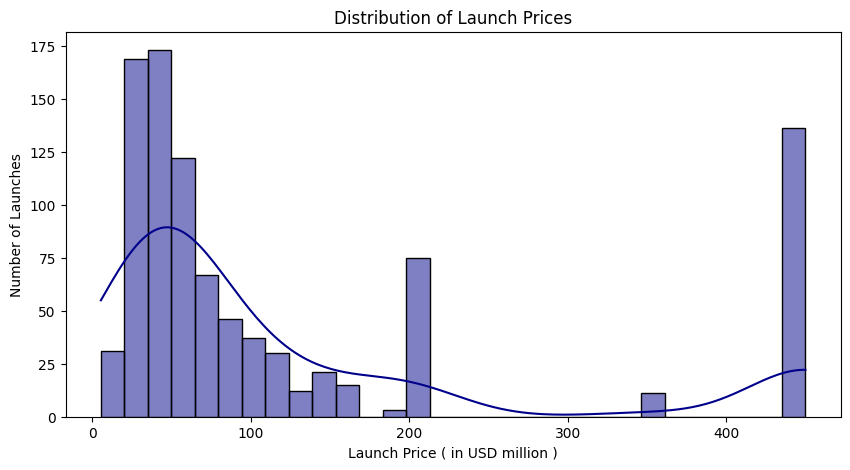

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(
    cleaned_df['Price'],
    bins=30,
    kde=True,
    color='darkblue'
)
plt.xlabel("Launch Price ( in USD million )")
plt.ylabel("Number of Launches")
plt.title("Distribution of Launch Prices")

plt.show()

In [20]:
cleaned_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China","Sat Jul 25, 2020 03:13 UTC","Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success


# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [21]:
def get_alpha3(country_names):

    # MANUAL CORRECTION FOR SPECIFIC COUNTRIES NAME
    custom_mapping = {
        "Russia": "RUS",
        "New Mexico": "USA",
        "Yellow Sea": "CHN",
        "Shahrud Missile Test Site": "IRN",
        "Pacific Missile Range Facility": "USA",
        "Barents Sea": "RUS",
        "Gran Canaria": "USA"
    }

    country_names = country_names.split(",")[-1].strip()

    if country_names in custom_mapping:
        return custom_mapping[country_names]
    
    try:
        return countries.get(country_names).alpha3
    except KeyError:
        return "Unknown"


In [29]:
cleaned_df["Country_Alpha3"] = cleaned_df["Location"].apply(get_alpha3)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948 entries, 0 to 4020
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Organisation    948 non-null    object 
 1   Location        948 non-null    object 
 2   Date            948 non-null    object 
 3   Detail          948 non-null    object 
 4   Rocket_Status   948 non-null    object 
 5   Price           948 non-null    float64
 6   Mission_Status  948 non-null    object 
 7   Country_Alpha3  948 non-null    object 
dtypes: float64(1), object(7)
memory usage: 66.7+ KB


# Use a Choropleth Map to Show the Number of Failures by Country


In [23]:
failure_df = cleaned_df[cleaned_df["Mission_Status"] == "Failure"]
failure_by_country = failure_df["Country_Alpha3"].value_counts().reset_index()
failure_by_country.head()

,Country_Alpha3,count
0,USA,20
1,IND,5
2,CHN,4
3,NZL,2
4,FRA,2


In [28]:
fig = px.choropleth(
    failure_by_country,
    locations="Country_Alpha3",
    locationmode="ISO-3",
    color="count",
    color_continuous_scale="Reds",
    title="Rocket Launch Failures by Country"
)
fig.update_layout(margin={"r":0,"t":100,"l":0,"b":100})
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [34]:
fig = px.sunburst(
    cleaned_df,
    path=['Country_Alpha3', 'Organisation', 'Mission_Status'],
    title="Rocket Launches by Country, Organisation and Mission Status",
    color="Mission_Status",
    color_discrete_map={'Success': 'green', 'Failure': 'red', 'Partial Failure': 'orange', 'Prelaunch Failure': 'purple'}
)
fig.update_layout(width=900, height=700)
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [37]:
total_spending = cleaned_df.groupby('Organisation')['Price'].sum().sort_values(ascending=False).reset_index()
total_spending.head()

,Organisation,Price
0,NASA,"61,200.00"
1,Arianespace,"16,345.00"
2,ULA,"14,798.00"
3,CASC,"6,310.51"
4,SpaceX,"5,444.00"


In [41]:
fig = px.bar(
    total_spending,
    x="Organisation",
    y="Price",
    title="Total Amount Spent by Organisation On Space Missions",
    labels={"Price": "Total Amount Spent ( in USD million )"},
    color="Price",
    color_continuous_scale="Viridis"
)
fig.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [43]:
spending_per_launch = cleaned_df.groupby("Organisation").agg(
    Total_Spending=("Price", "sum"),
    Launch_Count=("Organisation", "count")
)
spending_per_launch.head()

,Total_Spending,Launch_Count
Organisation,,
Arianespace,"16,345.00",96
Boeing,"1,241.00",7
CASC,"6,310.51",157
EER,20.00,1
ESA,37.00,1


In [44]:
spending_per_launch["Avg_cost_per_launch"] = spending_per_launch["Total_Spending"] / spending_per_launch["Launch_Count"]
spending_per_launch = spending_per_launch.sort_values(by="Avg_cost_per_launch", ascending=False).reset_index()
spending_per_launch.head()

,Organisation,Total_Spending,Launch_Count,Avg_cost_per_launch
0,NASA,"61,200.00",136,450.00
1,Boeing,"1,241.00",7,177.29
2,Arianespace,"16,345.00",96,170.26
3,ULA,"14,798.00",98,151.00
4,ILS,"1,320.00",13,101.54


In [64]:

fig = px.bar(
    spending_per_launch,
    x="Organisation",
    y="Avg_cost_per_launch",
    title="Average Cost Per Launch by Organisation",
    labels={"Avg_cost_per_launch": "Avg Cost per Launch (in USD Millions)"},
    color="Avg_cost_per_launch",
    color_continuous_scale="burgyl"
)

fig.show()

# Chart the Number of Launches per Year

In [92]:
cleaned_df['Year'] = cleaned_df["Date"].dt.year
launched_per_year = cleaned_df["Year"].value_counts().sort_index()
launched_per_year.head()

Year
1964    2
1965    2
1966    3
1967    7
1968    8
Name: count, dtype: int64

In [93]:
fig = px.line(
    x=launched_per_year.index,
    y=launched_per_year.values,
    title="Number of Space Launches per Year",
    labels={"x": "Year", "y": "Number of Launches"},
    markers=True
)

fig.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

## Chart the Total Number of Mission Failures Year on Year.

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 